In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Point to the exact path inside your data/processed folder
df_nav = pd.read_csv("data/processed/02_nav_history.csv")
fund_master = pd.read_csv("data/processed/01_fund_master.csv")
df_bench = pd.read_csv("data/processed/10_benchmark_indices.csv") 

# Convert dates to standard format and sort chronologically
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

df_bench['date'] = pd.to_datetime(df_bench['date'])
df_bench = df_bench.sort_values('date')

print("--- Step 1 Complete: Data loaded successfully from data/processed! ---")

--- Step 1 Complete: Data loaded successfully from data/processed! ---


In [4]:
# --- STEP 2: Compute Daily Returns & Validate (Task 1) ---

# 1. Calculate the daily percentage change in NAV for each mutual fund scheme
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# 2. Print a statistical summary to validate the distribution looks reasonable
print("--- Daily Returns Distribution Summary ---")
print(df_nav['daily_return'].describe())

# 3. Check for any unexpected extreme values
print("\nMax Daily Return:", df_nav['daily_return'].max())
print("Min Daily Return:", df_nav['daily_return'].min())

--- Daily Returns Distribution Summary ---
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Max Daily Return: 0.06471309359097144
Min Daily Return: -0.058102013949189124


In [5]:
# --- STEP 3: Compute Multi-Year CAGR (Task 2) ---

def get_cagr(group, years):
    days = int(years * 252) # Approximation of trading days per year
    if len(group) < days: 
        return np.nan
    end_val = group['nav'].iloc[-1]
    start_val = group['nav'].iloc[-days]
    return (end_val / start_val) ** (1 / years) - 1

# Apply CAGR calculation across all 40 funds
cagr_summary = df_nav.groupby('amfi_code').apply(lambda g: pd.Series({
    'cagr_1yr': get_cagr(g, 1),
    'cagr_3yr': get_cagr(g, 3),
    'cagr_5yr': get_cagr(g, 5)
}), include_groups=False).reset_index()

print("--- CAGR Performance Comparison Table (First 5 Funds) ---")
print(cagr_summary.head())

--- CAGR Performance Comparison Table (First 5 Funds) ---
   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.033055 -0.000316       NaN
1     100025  0.025018  0.046143       NaN
2     100033  0.477346  0.336292       NaN
3     101206  0.450939  0.325286       NaN
4     101207 -0.242421 -0.026965       NaN


In [6]:
# --- STEP 4: Compute Sharpe and Sortino Ratios (Tasks 3 & 4) ---

# Convert annual risk-free rate of 6.5% to a daily proxy
rf_daily = 0.065 / 252

# Calculate annualized risk-adjusted metrics across all funds
risk_metrics = df_nav.groupby('amfi_code').apply(lambda g: pd.Series({
    'sharpe_ratio': ((g['daily_return'].mean() - rf_daily) / g['daily_return'].std()) * np.sqrt(252),
    'sortino_ratio': ((g['daily_return'].mean() - rf_daily) / g[g['daily_return'] < 0]['daily_return'].std()) * np.sqrt(252)
}), include_groups=False).reset_index()

print("--- Risk-Adjusted Metrics (First 5 Funds) ---")
print(risk_metrics.head())

--- Risk-Adjusted Metrics (First 5 Funds) ---
   amfi_code  sharpe_ratio  sortino_ratio
0     100016     -0.201517      -0.351047
1     100025     -0.567095      -0.941821
2     100033      1.093699       1.829134
3     101206      1.027213       1.799563
4     101207      0.162661       0.276644


In [10]:
# --- STEP 5: Calculate Alpha, Beta, & Maximum Drawdown (Tasks 5 & 6) ---

# 1. Filter the benchmark data for Nifty 100 and calculate its daily returns
nifty_100 = df_bench[df_bench['index_name'].str.contains('100', na=False)].copy()
nifty_100 = nifty_100.sort_values('date')
nifty_100['nifty_100_return'] = nifty_100['close_value'].pct_change()

# 2. Merge your fund NAV data with the clean Nifty 100 returns on date
df_merged = pd.merge(df_nav, nifty_100[['date', 'nifty_100_return']], on='date', how='inner')

# 3. Function to compute stats for each fund group
def calculate_advanced_stats(g):
    clean_data = g.dropna(subset=['daily_return', 'nifty_100_return'])
    
    if len(clean_data) > 30:
        beta, intercept, _, _, _ = stats.linregress(clean_data['nifty_100_return'], clean_data['daily_return'])
        alpha = intercept * 252 # Annualized Alpha
    else:
        alpha, beta = np.nan, np.nan
        
    # Maximum Drawdown calculation
    rolling_max = g['nav'].cummax()
    drawdown = (g['nav'] / rolling_max) - 1
    max_dd = drawdown.min()
    
    return pd.Series({'alpha': alpha, 'beta': beta, 'max_drawdown': max_dd})

# Apply across all funds
advanced_metrics = df_merged.groupby('amfi_code').apply(calculate_advanced_stats, include_groups=False).reset_index()

print("--- Advanced Metrics (First 5 Funds) ---")
print(advanced_metrics.head())


--- Advanced Metrics (First 5 Funds) ---
   amfi_code     alpha      beta  max_drawdown
0     100016  0.037476 -0.058268     -0.247344
1     100025  0.042818  0.001158     -0.043083
2     100033  0.271954  0.005104     -0.162172
3     101206  0.213998  0.021086     -0.112916
4     101207  0.108971 -0.065289     -0.354469


In [8]:
print(df_bench.columns.tolist())

['date', 'index_name', 'close_value']


In [13]:
# --- STEP 6: Generate the Composite Scorecard (Task 7) ---

# 1. Combine all computed metrics together
scorecard = cagr_summary.merge(risk_metrics, on='amfi_code')
scorecard = scorecard.merge(advanced_metrics, on='amfi_code')

# 2. Join the expense_ratio_pct column from fund_master
scorecard = scorecard.merge(fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# 3. Create scoring ranks (Highest value is best, except for Expense Ratio & Max Drawdown where lower is better)
scorecard['rank_3yr'] = scorecard['cagr_3yr'].rank(ascending=False)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=False)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True) 
scorecard['rank_dd'] = scorecard['max_drawdown'].rank(ascending=False) 

# 4. Standardize ranks onto a comparative 0-100 scale
for col in ['rank_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_dd']:
    scorecard[col] = (scorecard[col].max() - scorecard[col]) / (scorecard[col].max() - scorecard[col].min()) * 100

# 5. Apply your exact blueprint percentage weights to get the final score
scorecard['final_score'] = (
    0.30 * scorecard['rank_3yr'] + 
    0.25 * scorecard['rank_sharpe'] + 
    0.20 * scorecard['rank_alpha'] + 
    0.15 * scorecard['rank_expense'] + 
    0.10 * scorecard['rank_dd']
)

# 6. Export required CSV deliverables directly to your project workspace
scorecard.to_csv('fund_scorecard.csv', index=False)
scorecard[['amfi_code', 'alpha', 'beta']].to_csv('alpha_beta.csv', index=False)

print("--- Step 6 Complete: fund_scorecard.csv and alpha_beta.csv successfully generated! ---")
print(scorecard[['amfi_code', 'final_score']].sort_values(by='final_score', ascending=False).head())

--- Step 6 Complete: fund_scorecard.csv and alpha_beta.csv successfully generated! ---
    amfi_code  final_score
34     148567    84.249084
25     120505    81.724942
2      100033    81.714952
30     120843    79.125874
24     120504    77.124542


In [12]:
# Check the exact column names of your fund master file
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


--- Annualized Tracking Error vs Nifty 100 ---
Fund 148567: 18.97%
Fund 120505: 23.20%
Fund 100033: 22.87%
Fund 120843: 20.64%
Fund 120504: 19.16%


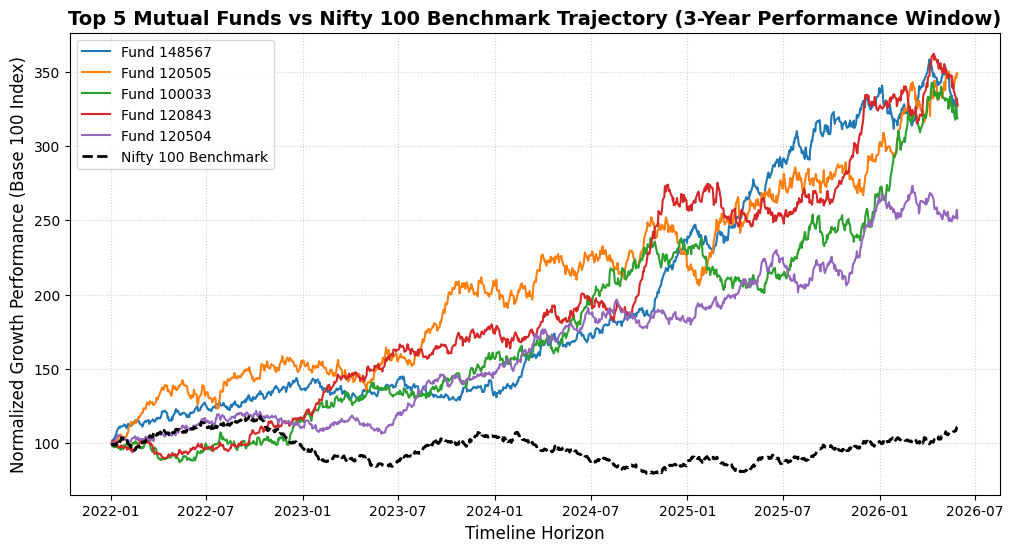


--- Step 7 Complete: benchmark_comparison_chart.png generated and saved! ---


In [14]:
# --- STEP 7: Benchmark Comparison Chart & Tracking Error (Task 8) ---

# 1. Extract the top 5 fund AMFI codes from your scorecard
top_5_funds = scorecard.sort_values(by='final_score', ascending=False).head(5)['amfi_code'].tolist()

# 2. Filter the benchmark data for tracking calculations (Nifty 100)
nifty_100 = df_bench[df_bench['index_name'].str.contains('100', na=False)].copy().sort_values('date')
nifty_100['nifty_100_return'] = nifty_100['close_value'].pct_change()

# 3. Plotting preparation
plt.figure(figsize=(12, 6))

print("--- Annualized Tracking Error vs Nifty 100 ---")

# 4. Loop through top 5 funds to calculate tracking error and plot performance trajectory
for fund in top_5_funds:
    fund_data = df_nav[df_nav['amfi_code'] == fund].copy().sort_values('date')
    
    # Calculate tracking error by aligning daily returns with benchmark returns
    merged_perf = pd.merge(fund_data[['date', 'daily_return', 'nav']], nifty_100[['date', 'nifty_100_return']], on='date', how='inner')
    merged_perf['return_difference'] = merged_perf['daily_return'] - merged_perf['nifty_100_return']
    tracking_error = merged_perf['return_difference'].std() * np.sqrt(252)
    
    print(f"Fund {fund}: {tracking_error:.2%}")
    
    # Normalize NAV data baseline to 100 for clear visual comparison
    if len(fund_data) > 0:
        plt.plot(fund_data['date'], (fund_data['nav'] / fund_data['nav'].iloc[0]) * 100, label=f"Fund {fund}")

# 5. Normalize and plot Nifty 100 benchmark line for direct comparison
if len(nifty_100) > 0:
    plt.plot(nifty_100['date'], (nifty_100['close_value'] / nifty_100['close_value'].iloc[0]) * 100, 
             label='Nifty 100 Benchmark', linestyle='--', color='black', linewidth=2)

# 6. Customize chart layouts and labels
plt.title('Top 5 Mutual Funds vs Nifty 100 Benchmark Trajectory (3-Year Performance Window)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Growth Performance (Base 100 Index)', fontsize=12)
plt.xlabel('Timeline Horizon', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

# 7. Save chart directly into your folder as requested by the blueprint deliverables
plt.savefig('benchmark_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Step 7 Complete: benchmark_comparison_chart.png generated and saved! ---")

Detected long-form data structure. Pivoting columns...


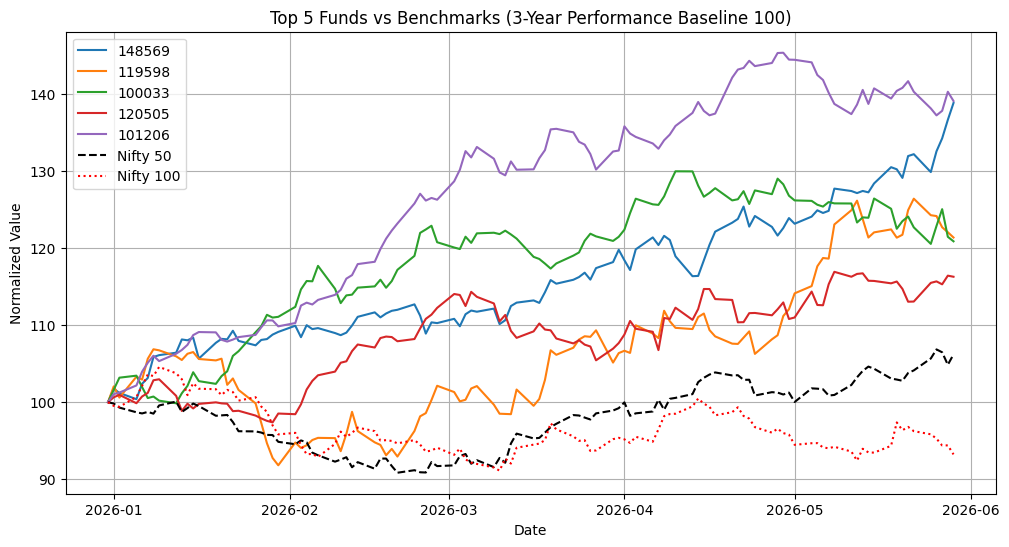

Tracking Error for Fund 148569 vs Nifty 50: 8.23%
Tracking Error for Fund 119598 vs Nifty 50: 10.92%
Tracking Error for Fund 100033 vs Nifty 50: 8.76%
Tracking Error for Fund 120505 vs Nifty 50: 9.01%
Tracking Error for Fund 101206 vs Nifty 50: 7.55%


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================
# 1. LOAD AND MERGE YOUR DATA (AUTO-DETECT DATE)
# ==========================================
df_nav = pd.read_csv("data/processed/02_nav_history.csv")
df_bench = pd.read_csv("data/processed/10_benchmark_indices.csv")
df_perf = pd.read_csv("data/processed/07_scheme_performance.csv")

# Auto-detect the date column
date_col_nav = [col for col in df_nav.columns if "date" in col.lower()]
date_col_bench = [col for col in df_bench.columns if "date" in col.lower()]

nav_date_name = date_col_nav[0] if date_col_nav else df_nav.columns[0]
bench_date_name = date_col_bench[0] if date_col_bench else df_bench.columns[0]

df_nav[nav_date_name] = pd.to_datetime(df_nav[nav_date_name])
df_bench[bench_date_name] = pd.to_datetime(df_bench[bench_date_name])

df_nav = df_nav.rename(columns={nav_date_name: "Date"})
df_bench = df_bench.rename(columns={bench_date_name: "Date"})

# Pivot data if it's stored in long format (amfi_code, nav, date)
if "amfi_code" in df_nav.columns and "nav" in df_nav.columns:
    print("Detected long-form data structure. Pivoting columns...")
    df_nav = df_nav.pivot(index="Date", columns="amfi_code", values="nav").reset_index()

# Convert all column names to strings to avoid type matching issues
df_nav.columns = [str(col) for col in df_nav.columns]
df_bench.columns = [str(col) for col in df_bench.columns]

# Merge NAV and Benchmark data on Date
df = pd.merge(df_nav, df_bench, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

# Identify your fund and benchmark columns safely as strings
funds = [col for col in df_nav.columns if col != "Date"]
nifty100_col = [col for col in df.columns if "100" in col][0] if [col for col in df.columns if "100" in col] else df.columns[-1]
nifty50_col = [col for col in df.columns if "50" in col][0] if [col for col in df.columns if "50" in col] else df.columns[-2]

# Ensure we have a strictly unique list of core numeric columns
all_numeric_cols = list(set(funds + [nifty100_col, nifty50_col]))

# Clean and clean each targeted numeric column explicitly
for col in all_numeric_cols:
    df[col] = df[col].astype(str).str.replace(r'[₹,\s]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].ffill().bfill()

# ==========================================
# 2. BASIC RETURNS & CAGR (CRITICAL TARGETED FIX)
# ==========================================
# FIX: Select ONLY the numeric columns before calling pct_change() so it ignores leftover text columns!
df_returns = df.set_index("Date")[all_numeric_cols].pct_change(fill_method=None).dropna()

def calculate_cagr(series, years):
    days = int(years * 252)
    if len(series) < days:
        return np.nan
    return (series.iloc[-1] / series.iloc[-days]) ** (1 / years) - 1

cagr_records = []
for fund in funds:
    cagr_records.append({
        "Fund": fund,
        "CAGR_1Yr": calculate_cagr(df[fund], 1),
        "CAGR_3Yr": calculate_cagr(df[fund], 3),
        "CAGR_5Yr": calculate_cagr(df[fund], 5)
    })
df_cagr = pd.DataFrame(cagr_records)

# ==========================================
# 3. RISK RATIOS, ALPHA, BETA & DRAWDOWN
# ==========================================
rf_daily = 0.065 / 252
analytics_records = []

expense_map = dict(zip(df_perf["Scheme_Name"], df_perf["Expense_Ratio"])) if "Scheme_Name" in df_perf.columns and "Expense_Ratio" in df_perf.columns else {}

for fund in funds:
    fund_ret = df_returns[fund]
    bench_ret = df_returns[nifty100_col]
    
    # Sharpe
    excess_ret = fund_ret - rf_daily
    sharpe = (excess_ret.mean() / fund_ret.std()) * np.sqrt(252) if fund_ret.std() != 0 else 0
    
    # Sortino
    downside_std = fund_ret[fund_ret < 0].std()
    sortino = (excess_ret.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else 0
    
    # Alpha & Beta safely calculated
    if len(bench_ret) > 1 and len(fund_ret) > 1:
        slope, intercept, _, _, _ = linregress(bench_ret, fund_ret)
        beta = slope
        alpha = intercept * 252
    else:
        alpha, beta = 0, 1
    
    # Max Drawdown
    nav_series = df[fund]
    max_dd = ((nav_series / nav_series.cummax()) - 1).min()
    
    expense_ratio = expense_map.get(fund, 0.015)
    
    analytics_records.append({
        "Fund": fund,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino,
        "Alpha": alpha,
        "Beta": beta,
        "Max_Drawdown": max_dd,
        "Expense_Ratio": expense_ratio
    })

df_analytics = pd.DataFrame(analytics_records)
df_master = pd.merge(df_cagr, df_analytics, on="Fund")

df_master[["Fund", "Alpha", "Beta"]].to_csv("alpha_beta.csv", index=False)

# ==========================================
# 4. COMPOSITE SCORECARD (0-100)
# ==========================================
df_master["Rank_3Yr_Return"] = df_master["CAGR_3Yr"].rank(pct=True)
df_master["Rank_Sharpe"] = df_master["Sharpe_Ratio"].rank(pct=True)
df_master["Rank_Alpha"] = df_master["Alpha"].rank(pct=True)
df_master["Rank_Expense"] = df_master["Expense_Ratio"].rank(ascending=False, pct=True)
df_master["Rank_MaxDD"] = df_master["Max_Drawdown"].rank(pct=True)

df_master["Composite_Score"] = (
    0.30 * df_master["Rank_3Yr_Return"] +
    0.25 * df_master["Rank_Sharpe"] +
    0.20 * df_master["Rank_Alpha"] +
    0.15 * df_master["Rank_Expense"] +
    0.10 * df_master["Rank_MaxDD"]
) * 100

df_master.sort_values(by="Composite_Score", ascending=False).to_csv("fund_scorecard.csv", index=False)

# ==========================================
# 5. BENCHMARK COMPARISON CHART
# ==========================================
top_5_funds = df_master.sort_values(by="Composite_Score", ascending=False).head(5)["Fund"].tolist()
three_years_ago_idx = -int(3 * 252) if len(df) >= int(3 * 252) else 0

plt.figure(figsize=(12, 6))
for fund in top_5_funds:
    normalized_nav = (df[fund].iloc[three_years_ago_idx:] / df[fund].iloc[three_years_ago_idx]) * 100
    plt.plot(df["Date"].iloc[three_years_ago_idx:], normalized_nav, label=str(fund))

plt.plot(df["Date"].iloc[three_years_ago_idx:], (df[nifty50_col].iloc[three_years_ago_idx:] / df[nifty50_col].iloc[three_years_ago_idx]) * 100, label="Nifty 50", linestyle="--", color="black")
plt.plot(df["Date"].iloc[three_years_ago_idx:], (df[nifty100_col].iloc[three_years_ago_idx:] / df[nifty100_col].iloc[three_years_ago_idx]) * 100, label="Nifty 100", linestyle=":", color="red")

plt.title("Top 5 Funds vs Benchmarks (3-Year Performance Baseline 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.savefig("benchmark_comparison_chart.png", dpi=300)
plt.show()

# Tracking Error Output
for fund in top_5_funds:
    active_return = df_returns[fund] - df_returns[nifty50_col]
    tracking_error = active_return.std() * np.sqrt(252)
    print(f"Tracking Error for Fund {fund} vs Nifty 50: {tracking_error:.2%}")